2026-03-10 18:09:56.387929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 18:09:56.428683: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 18:09:57.489839: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/fffeelipe/.conda/envs/torch_cuda/lib/python3.11/site-packages/keras/src/export/tf2onn

Using device: cuda
Loading existing slice_tumor_map from ./unpacked/T1/slice_tumor_map.json
Loaded 1806 slices: 870 with tumor, 936 without
Preloading 1806 images + masks into RAM...


/tmp/ipykernel_133085/1434029037.py:133: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
/tmp/ipykernel_133085/1434029037.py:140: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),


  Cached 1806 images + 1806 masks (533.9 MB)
Dataset balance: 870 positive, 936 negative slices


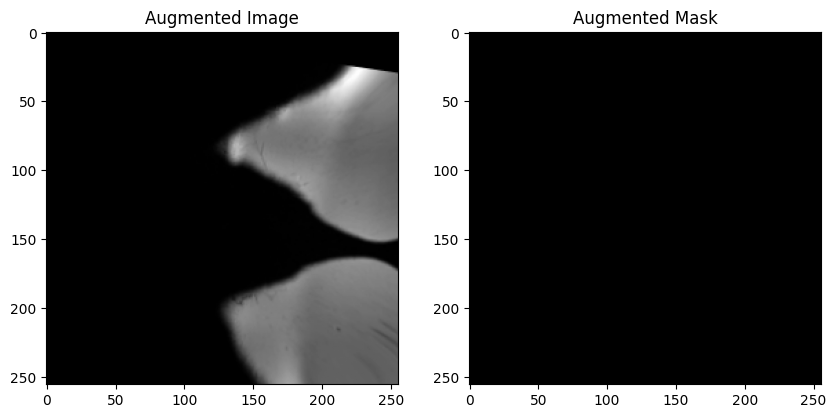

Model: smp.Unet | Encoder: efficientnet-b4 | Weights: imagenet
Total params: 20,302,254 | Trainable: 20,302,254
Total patients: 46

  FOLD 1/8
  Test  (6): ['IOG4', 'IOG40', 'IOG49', 'IOG53', 'IOG55', 'IOG7']
  Train (32), Val (8)
  Test slices: 209 (108 pos, 101 neg)
  Train pool: 628 pos, 675 neg
E01/50 LR=1.00e-04 T-L=0.7630 V-L=0.8011 T-D=0.0674 V-D=0.0234


In [ ]:
# %%
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.losses import TverskyLoss
from monai.losses import DiceLoss

from torch.utils.data import WeightedRandomSampler


import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler
import random
from concurrent.futures import ThreadPoolExecutor

SEED = 42

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f'Using device: {device}')

# %%
# Define paths
DATA_DIR = './T1/'
IMAGE_DIR = './unpacked/T1/images/'
MASK_DIR = './unpacked/T1/masks/'

# Create directories if they don't exist
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# Get a list of patient folders
patient_folders = sorted(glob.glob(os.path.join(DATA_DIR, 'IOG*')))

# %%
import json

SLICE_MAP_PATH = './unpacked/T1/slice_tumor_map.json'

def extract_and_save_slices(patient_folders, image_dir, mask_dir):
    """Extract slices and create a map tracking which have tumor segmentation."""
    slice_tumor_map = {}  # filename -> has_tumor (bool)
    
    for patient_folder in patient_folders:
        patient_id = os.path.basename(patient_folder)
        try:
            img_path = glob.glob(os.path.join(patient_folder, '*[!_roi].nii.gz'))[0]
            mask_path = glob.glob(os.path.join(patient_folder, '*_roi.nii.gz'))[0]

            img = nib.load(img_path).get_fdata()
            mask = nib.load(mask_path).get_fdata()

            # Normalize image to 0-255 and convert to uint8
            img = ((img - np.min(img)) / (np.max(img) - np.min(img)) * 255).astype(np.uint8)
            mask = (mask > 0).astype(np.uint8) * 255 # Binarize mask

            # Assuming axial slices are the last dimension
            for i in range(img.shape[2]):
                img_slice = Image.fromarray(img[:, :, i])
                mask_slice = Image.fromarray(mask[:, :, i])
                
                filename = f'{patient_id}_slice_{i}.png'
                has_tumor = bool(np.sum(np.array(mask_slice)) > 0)
                slice_tumor_map[filename] = has_tumor
                
                img_slice.save(os.path.join(image_dir, filename))
                mask_slice.save(os.path.join(mask_dir, filename))
                
        except IndexError:
            print(f'Skipping {patient_id} due to missing files.')
    
    # Save the map
    with open(SLICE_MAP_PATH, 'w') as f:
        json.dump(slice_tumor_map, f)
    
    pos = sum(slice_tumor_map.values())
    neg = len(slice_tumor_map) - pos
    print(f'Saved {len(slice_tumor_map)} slices: {pos} with tumor, {neg} without')
    return slice_tumor_map

# Skip extraction if data already exists
if os.path.exists(SLICE_MAP_PATH) and os.path.exists(IMAGE_DIR) and len(os.listdir(IMAGE_DIR)) > 0:
    print(f'Loading existing slice_tumor_map from {SLICE_MAP_PATH}')
    with open(SLICE_MAP_PATH, 'r') as f:
        slice_tumor_map = json.load(f)
    pos = sum(slice_tumor_map.values())
    neg = len(slice_tumor_map) - pos
    print(f'Loaded {len(slice_tumor_map)} slices: {pos} with tumor, {neg} without')
else:
    slice_tumor_map = extract_and_save_slices(patient_folders, IMAGE_DIR, MASK_DIR)
    print('Finished extracting and saving slices.')


# %%
# Define the augmentation pipeline for the training set
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
    A.Affine(
        rotate=(-15, 15),
        scale=(0.9, 1.1),
        translate_percent=0.05,
        p=0.75
    ),
    A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Define a simpler pipeline for the validation set (no augmentations)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Load the slice tumor map
def load_slice_tumor_map():
    if os.path.exists(SLICE_MAP_PATH):
        with open(SLICE_MAP_PATH, 'r') as f:
            return json.load(f)
    return {}

slice_tumor_map = load_slice_tumor_map()


class ImageCache:
    """Preloads all images and masks into RAM using parallel I/O threads."""

    def __init__(self, image_paths, mask_paths, num_threads=16):
        self.images = {}
        self.masks = {}
        print(f'Preloading {len(image_paths)} images + masks into RAM...', flush=True)

        def _load_gray(path):
            return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        with ThreadPoolExecutor(max_workers=num_threads) as pool:
            loaded_imgs = list(pool.map(_load_gray, image_paths))
            loaded_msks = list(pool.map(_load_gray, mask_paths))

        for path, img in zip(image_paths, loaded_imgs):
            self.images[path] = img
        for path, msk in zip(mask_paths, loaded_msks):
            self.masks[path] = (msk > 0).astype(np.uint8) * 255

        mem_mb = (sum(v.nbytes for v in self.images.values()) +
                  sum(v.nbytes for v in self.masks.values())) / 1024**2
        print(f'  Cached {len(self.images)} images + {len(self.masks)} masks ({mem_mb:.1f} MB)')


class LipomaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, slice_tumor_map=None, cache=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.slice_tumor_map = slice_tumor_map or {}
        self.cache = cache
        
        self.has_tumor = []
        for img_path in self.image_paths:
            filename = os.path.basename(img_path)
            self.has_tumor.append(self.slice_tumor_map.get(filename, True))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        if self.cache is not None:
            image = self.cache.images[image_path]
            mask = self.cache.masks[mask_path]
        else:
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.uint8) * 255

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        # Ensure mask tensor is binary (0 or 1) and has a channel dimension
        mask = (mask > 0.5).float().unsqueeze(0)

        return image, mask
    
    def get_balanced_sampler(self, neg_to_pos_ratio=1.0):
        """Create a WeightedRandomSampler to balance positive/negative samples.
        
        Args:
            neg_to_pos_ratio: Target ratio of negative to positive samples (1.0 = equal)
        """
        n_pos = sum(self.has_tumor)
        n_neg = len(self.has_tumor) - n_pos
        
        if n_pos == 0 or n_neg == 0:
            return None
        
        # Calculate weights: higher weight for minority class
        # For balanced sampling: weight_pos * n_pos = weight_neg * n_neg
        weight_pos = 1.0
        weight_neg = (n_pos / n_neg) * neg_to_pos_ratio
        
        weights = [weight_pos if has_tumor else weight_neg for has_tumor in self.has_tumor]
        
        return WeightedRandomSampler(
            weights=weights,
            num_samples=len(weights),
            replacement=True
        )

# Create a placeholder dataset to get all image/mask paths
all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))
all_masks = sorted(glob.glob(os.path.join(MASK_DIR, '*.png')))

image_cache = ImageCache(all_images, all_masks, num_threads=16)

if slice_tumor_map:
    n_pos = sum(1 for img in all_images if slice_tumor_map.get(os.path.basename(img), True))
    n_neg = len(all_images) - n_pos
    print(f'Dataset balance: {n_pos} positive, {n_neg} negative slices')


# Demonstrate the augmentation by showing an example
if len(all_images) > 0:
    temp_dataset = LipomaDataset(image_paths=all_images, mask_paths=all_masks, 
                                  transform=train_transform, slice_tumor_map=slice_tumor_map,
                                  cache=image_cache)
    image, mask = temp_dataset[0]
    
    # Reverse normalization for visualization
    image = (image * 0.5) + 0.5
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image.squeeze(), cmap='gray')
    ax[0].set_title('Augmented Image')
    ax[1].imshow(mask.squeeze(), cmap='gray')
    ax[1].set_title('Augmented Mask')
    plt.show()


# %%
ENCODER_NAME = 'efficientnet-b4'
ENCODER_WEIGHTS = 'imagenet'
IN_CHANNELS = 1
OUT_CHANNELS = 1
DECODER_CHANNELS = (256, 128, 64, 32, 16)  # Default decoder channel sizes

def build_model():
    """Build smp U-Net with pre-trained EfficientNet-B4 encoder and scSE attention decoder."""
    return smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=OUT_CHANNELS,
        decoder_attention_type='scse',
        decoder_channels=DECODER_CHANNELS,
    )

model = build_model().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: smp.Unet | Encoder: {ENCODER_NAME} | Weights: {ENCODER_WEIGHTS}')
print(f'Total params: {total_params:,} | Trainable: {trainable_params:,}')                                                                                                                                 

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt

class BoundaryLoss(nn.Module):
    """Boundary loss using distance transform."""
    def __init__(self):
        super().__init__()
    
    def compute_distance_map(self, mask):
        """Compute signed distance map: negative inside, positive outside."""
        mask_np = mask.cpu().numpy()
        batch_size = mask_np.shape[0]
        dist_maps = []
        
        for b in range(batch_size):
            m = mask_np[b, 0]
            if m.sum() == 0:  # Empty mask
                dist_maps.append(np.ones_like(m))  # All positive (penalize any prediction)
            else:
                # Negative inside (want pred=1), positive outside (want pred=0)
                pos_dist = distance_transform_edt(m)
                neg_dist = distance_transform_edt(1 - m)
                dist_map = pos_dist - neg_dist
                # Normalize to [-1, 1] range
                dist_map = np.clip(dist_map / (np.abs(dist_map).max() + 1e-8), -1, 1)
                dist_maps.append(dist_map)
        
        return torch.tensor(np.stack(dist_maps), dtype=torch.float32, device=mask.device).unsqueeze(1)
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        dist_map = self.compute_distance_map(target)
        # Minimize: pred * dist_map (negative where we want pred=1, positive where pred=0)
        boundary_loss = (pred_sig * dist_map).mean()
        return boundary_loss

class DiceLoss(nn.Module):
    """Standard dice loss, handles empty masks."""
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        pred_flat = pred_sig.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

class FocalLoss(nn.Module):
    """Focal loss for handling class imbalance."""
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        bce = F.binary_cross_entropy_with_logits(pred_flat, target_flat, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

class CombinedLoss(nn.Module):
    """Dice + Focal + Boundary loss."""
    def __init__(self, dice_weight=0.5, focal_weight=0.3, boundary_weight=0.2):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.boundary = BoundaryLoss()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.boundary_weight = boundary_weight
    
    def forward(self, pred, target):
        d_loss = self.dice(pred, target)
        f_loss = self.focal(pred, target)
        b_loss = self.boundary(pred, target)
        
        total = self.dice_weight * d_loss + self.focal_weight * f_loss + self.boundary_weight * b_loss
        return total
                                                                                                                                                                                                            

# %%
# Hyperparameters
LEARNING_RATE = 3e-4
BATCH_SIZE = 32
NUM_WORKERS = 8
NUM_EPOCHS = 50
NUM_FOLDS = 8
NEG_SAMPLE_RATIO = 0.5
EARLY_STOP_PATIENCE = 10
WARMUP_EPOCHS = 3
ENCODER_FREEZE_EPOCHS = 5
NUM_PREDICTION_EXAMPLES = 10
USE_AMP = (device == 'cuda')
VAL_SPLIT_RATIO = 0.2  # fraction of training patients used for validation (early stopping)

# %%


# Post-processing refinement: morphological ops + component filtering + hole filling
def postprocess_mask(pred_mask, min_component_size=50, morph_kernel_size=5):
    """Refine predictions with morphological closing/opening, small component removal, and hole filling."""
    from scipy import ndimage
    pred_np = pred_mask.cpu().numpy() if torch.is_tensor(pred_mask) else pred_mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))

    processed = []
    for i in range(pred_np.shape[0]):
        mask = (pred_np[i, 0] > 0.5).astype(np.uint8)
        if mask.sum() == 0:
            processed.append(mask.astype(np.float32))
            continue

        # Morphological closing (fill small gaps) then opening (remove noise)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        labeled, num_features = ndimage.label(mask)
        if num_features == 0:
            processed.append(mask.astype(np.float32))
            continue

        # Remove components smaller than threshold
        sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
        for label_idx, size in enumerate(sizes, 1):
            if size < min_component_size:
                mask[labeled == label_idx] = 0

        # Fill holes inside remaining regions
        mask = ndimage.binary_fill_holes(mask).astype(np.float32)
        processed.append(mask)

    return torch.tensor(np.stack(processed), device=pred_mask.device).unsqueeze(1)

# Test-Time Augmentation
def tta_predict(model, image):
    """Apply test-time augmentation: original + flips."""
    model.eval()
    with torch.no_grad(), autocast(device_type='cuda', enabled=USE_AMP):
        logits = []
        
        # Original
        logits.append(model(image))
        
        # Horizontal flip
        img_hflip = torch.flip(image, dims=[3])
        logits.append(torch.flip(model(img_hflip), dims=[3]))
        
        # Vertical flip
        img_vflip = torch.flip(image, dims=[2])
        logits.append(torch.flip(model(img_vflip), dims=[2]))
        
        # Both flips
        img_both = torch.flip(image, dims=[2, 3])
        logits.append(torch.flip(model(img_both), dims=[2, 3]))
        
        # Average logits, then sigmoid
        return torch.sigmoid(torch.stack(logits).mean(dim=0))

# Cosine annealing with warmup scheduler
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        
    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

# Early stopping tracker
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.should_stop

# Dice coefficient metric (separate from loss)
def dice_metric(pred, target, threshold=0.5):
    smooth = 1.0
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    
    # Per-sample dice
    intersection = (pred_bin * target).sum(dim=(2, 3))
    pred_sum = pred_bin.sum(dim=(2, 3))
    target_sum = target.sum(dim=(2, 3))
    union = pred_sum + target_sum
    
    # Handle empty masks: if both pred and target empty, dice=1
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # For empty targets where pred is also empty, set dice to 1
    empty_correct = ((target_sum == 0) & (pred_sum < 10)).float()  # Allow small noise
    dice = dice * (1 - empty_correct) + empty_correct
    
    return dice.mean()

# Training and Validation Functions
def train_epoch(loader, model, optimizer, loss_fn, scaler=None):
    model.train()
    total_loss = 0
    total_dice = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', enabled=USE_AMP):
            preds = model(images)
            loss = loss_fn(preds, masks)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total_loss += loss.item()
        total_dice += dice_metric(preds.float(), masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def validate_epoch(loader, model, loss_fn, use_tta=False, use_postprocess=False):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad(), autocast(device_type='cuda', enabled=USE_AMP):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            
            if use_tta:
                preds_probs = tta_predict(model, images)
                preds = torch.logit(preds_probs.clamp(1e-6, 1-1e-6))
            else:
                preds = model(images)
            
            loss = loss_fn(preds.float(), masks)
            
            if use_postprocess:
                preds_processed = postprocess_mask(torch.sigmoid(preds.float()))
                pred_logits = torch.logit(preds_processed.clamp(1e-6, 1-1e-6))
                total_dice += dice_metric(pred_logits, masks).item()
            else:
                total_dice += dice_metric(preds.float(), masks).item()
            
            total_loss += loss.item()
    return total_loss / len(loader), total_dice / len(loader)

def evaluate_per_patient(model, patient_ids, all_images, all_masks, transform,
                         slice_tumor_map, use_tta=False, use_postprocess=False, cache=None):
    """Compute volume-level DICE per patient (all slices, including empty ones)."""
    model.eval()
    results = {}
    for patient_id in patient_ids:
        pat_imgs = [p for p in all_images if os.path.basename(p).split('_slice_')[0] == patient_id]
        pat_msks = [p for p in all_masks  if os.path.basename(p).split('_slice_')[0] == patient_id]
        if not pat_imgs:
            continue
        ds = LipomaDataset(pat_imgs, pat_msks, transform, slice_tumor_map, cache=cache)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        all_preds, all_tgts = [], []
        with torch.no_grad(), autocast(device_type='cuda', enabled=USE_AMP):
            for imgs, msks in loader:
                imgs = imgs.to(device)
                if use_tta:
                    probs = tta_predict(model, imgs)
                else:
                    probs = torch.sigmoid(model(imgs))
                if use_postprocess:
                    probs = postprocess_mask(probs)
                all_preds.append((probs > 0.5).float().cpu())
                all_tgts.append(msks.cpu())
        all_preds = torch.cat(all_preds)
        all_tgts  = torch.cat(all_tgts)
        smooth = 1e-5
        intersection = (all_preds * all_tgts).sum()
        p_sum, t_sum = all_preds.sum(), all_tgts.sum()
        if p_sum == 0 and t_sum == 0:
            dice = 1.0
        else:
            dice = ((2.0 * intersection + smooth) / (p_sum + t_sum + smooth)).item()
        n_tumor = sum(1 for p in pat_imgs if slice_tumor_map.get(os.path.basename(p), False))
        results[patient_id] = {'dice': dice, 'n_slices': len(pat_imgs), 'n_tumor_slices': n_tumor}
    return results

# ── 5-Fold Cross-Validation (each fold = test set, no global holdout) ──
seed_everything(SEED)
patient_ids = sorted(set(os.path.basename(p).split('_slice_')[0] for p in all_images))
print(f'Total patients: {len(patient_ids)}')

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
all_patient_results = {}

criterion = CombinedLoss(dice_weight=0.8, focal_weight=0.15, boundary_weight=0.05)

for fold, (train_val_idx, test_idx) in enumerate(kf.split(patient_ids)):
    print(f'\n{"="*60}')
    print(f'  FOLD {fold+1}/{NUM_FOLDS}')
    print(f'{"="*60}')
    seed_everything(SEED + fold)

    test_patients  = [patient_ids[i] for i in test_idx]
    train_val_list = [patient_ids[i] for i in train_val_idx]

    n_val = max(1, int(len(train_val_list) * VAL_SPLIT_RATIO))
    np.random.shuffle(train_val_list)
    val_patients   = train_val_list[:n_val]
    train_patients = train_val_list[n_val:]

    print(f'  Test  ({len(test_patients)}): {test_patients}')
    print(f'  Train ({len(train_patients)}), Val ({len(val_patients)})')

    train_images = [p for p in all_images if os.path.basename(p).split('_slice_')[0] in train_patients]
    train_masks  = [p for p in all_masks  if os.path.basename(p).split('_slice_')[0] in train_patients]
    val_images   = [p for p in all_images if os.path.basename(p).split('_slice_')[0] in val_patients]
    val_masks    = [p for p in all_masks  if os.path.basename(p).split('_slice_')[0] in val_patients]
    test_images  = [p for p in all_images if os.path.basename(p).split('_slice_')[0] in test_patients]
    test_masks   = [p for p in all_masks  if os.path.basename(p).split('_slice_')[0] in test_patients]

    test_pos = sum(1 for p in test_images if slice_tumor_map.get(os.path.basename(p), False))
    print(f'  Test slices: {len(test_images)} ({test_pos} pos, {len(test_images)-test_pos} neg)')

    pos_images     = [p for p in train_images if     slice_tumor_map.get(os.path.basename(p), False)]
    pos_masks      = [p for p in train_masks  if     slice_tumor_map.get(os.path.basename(p).replace('_mask',''), False)]
    all_neg_images = [p for p in train_images if not slice_tumor_map.get(os.path.basename(p), False)]
    all_neg_masks  = [p for p in train_masks  if not slice_tumor_map.get(os.path.basename(p).replace('_mask',''), False)]
    total_neg = len(all_neg_images)
    print(f'  Train pool: {len(pos_images)} pos, {total_neg} neg')

    val_dataset = LipomaDataset(val_images, val_masks, val_transform, slice_tumor_map, cache=image_cache)
    val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    model = build_model().to(device)
    for param in model.encoder.parameters():
        param.requires_grad = False
    encoder_frozen = True

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
    scheduler = WarmupCosineScheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)
    early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)
    scaler = GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [], 'lr': []}
    best_val_dice = -1.0

    for epoch in range(NUM_EPOCHS):
        if encoder_frozen and epoch >= ENCODER_FREEZE_EPOCHS:
            for param in model.encoder.parameters():
                param.requires_grad = True
            encoder_frozen = False
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE * 0.1)
            scheduler = WarmupCosineScheduler(optimizer, 0, NUM_EPOCHS - epoch)
            print(f'  >> Encoder unfrozen at epoch {epoch+1}')

        neg_ratio = NEG_SAMPLE_RATIO * (epoch / max(NUM_EPOCHS - 1, 1))
        n_neg = int(total_neg * neg_ratio)
        if n_neg > 0:
            idx = np.random.choice(total_neg, n_neg, replace=False)
            ep_neg_imgs = [all_neg_images[i] for i in idx]
            ep_neg_msks = [all_neg_masks[i]  for i in idx]
        else:
            ep_neg_imgs, ep_neg_msks = [], []

        ep_imgs = pos_images + ep_neg_imgs
        ep_msks = pos_masks  + ep_neg_msks

        train_dataset = LipomaDataset(ep_imgs, ep_msks, train_transform, slice_tumor_map, cache=image_cache)
        train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                     num_workers=NUM_WORKERS, pin_memory=True)

        lr = scheduler.step(epoch)
        train_loss, train_dice = train_epoch(train_loader, model, optimizer, criterion, scaler)
        val_loss, val_dice = validate_epoch(val_loader, model, criterion)

        print(f'E{epoch+1:02d}/{NUM_EPOCHS} LR={lr:.2e} '
              f'T-L={train_loss:.4f} V-L={val_loss:.4f} '
              f'T-D={train_dice:.4f} V-D={val_dice:.4f}')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['lr'].append(lr)

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f'best_2D_model_fold_{fold+1}.pth')

        if early_stopping(val_loss):
            print(f'  Early stopping at epoch {epoch+1}')
            break

    # ── Evaluate on test fold (ALL slices, including empty) ──
    model.load_state_dict(torch.load(f'best_2D_model_fold_{fold+1}.pth'))

    test_dataset = LipomaDataset(test_images, test_masks, val_transform, slice_tumor_map, cache=image_cache)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    test_loss, test_dice         = validate_epoch(test_loader, model, criterion)
    test_loss_tta, test_dice_tta = validate_epoch(test_loader, model, criterion,
                                                   use_tta=True, use_postprocess=True)

    pat_res     = evaluate_per_patient(model, test_patients, all_images, all_masks,
                                       val_transform, slice_tumor_map, cache=image_cache)
    pat_res_tta = evaluate_per_patient(model, test_patients, all_images, all_masks,
                                       val_transform, slice_tumor_map,
                                       use_tta=True, use_postprocess=True, cache=image_cache)
    for pid in pat_res:
        pat_res[pid]['dice_tta'] = pat_res_tta[pid]['dice']
        pat_res[pid]['fold']     = fold + 1
        all_patient_results[pid] = pat_res[pid]

    print(f'\n  Test Dice: {test_dice:.4f} | TTA+PP: {test_dice_tta:.4f}')
    for pid, r in sorted(pat_res.items()):
        print(f'    {pid}: {r["dice"]:.4f} (TTA: {r["dice_tta"]:.4f})  '
              f'[{r["n_tumor_slices"]}/{r["n_slices"]} tumor slices]')

    fold_results.append({
        'history': history,
        'model_path': f'best_2D_model_fold_{fold+1}.pth',
        'test_patients': test_patients,
        'val_patients': val_patients,
        'best_val_dice': best_val_dice,
        'test_dice': test_dice,
        'test_dice_tta': test_dice_tta,
        'patient_results': pat_res,
    })

print('\n' + '='*60)
print('Finished 5-Fold Cross-Validation.')


# %%
import pandas as pd

# ── Training history plots ──
for i, result in enumerate(fold_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(result['history']['train_loss'], label='Train Loss')
    plt.plot(result['history']['val_loss'], label='Val Loss')
    plt.title(f'Fold {i+1} — Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(result['history']['train_dice'], label='Train Dice')
    plt.plot(result['history']['val_dice'], label='Val Dice')
    plt.title(f'Fold {i+1} — Dice Coefficient')
    plt.legend()
    plt.show()

# ── Qualitative predictions from best fold ──
best_fold_idx = int(np.argmax([r['test_dice_tta'] for r in fold_results]))
print(f'Showing predictions from Fold {best_fold_idx+1} (best test Dice TTA+PP).\n')

model = build_model().to(device)
model.load_state_dict(torch.load(fold_results[best_fold_idx]['model_path']))
model.eval()

t_pats = fold_results[best_fold_idx]['test_patients']
t_imgs = [p for p in all_images if os.path.basename(p).split('_slice_')[0] in t_pats]
t_msks = [p for p in all_masks  if os.path.basename(p).split('_slice_')[0] in t_pats]
t_ds = LipomaDataset(t_imgs, t_msks, val_transform, slice_tumor_map, cache=image_cache)
t_loader = DataLoader(t_ds, batch_size=NUM_PREDICTION_EXAMPLES, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)

with torch.no_grad():
    images, masks = next(iter(t_loader))
    images, masks = images.to(device), masks.to(device)
    preds = torch.sigmoid(model(images))
    n_show = min(NUM_PREDICTION_EXAMPLES, len(images))
    plt.figure(figsize=(15, 5 * n_show))
    for i in range(n_show):
        plt.subplot(n_show, 3, i*3 + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray'); plt.title('Image'); plt.axis('off')
        plt.subplot(n_show, 3, i*3 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray'); plt.title('Ground Truth'); plt.axis('off')
        plt.subplot(n_show, 3, i*3 + 3)
        plt.imshow(preds[i].cpu().squeeze() > 0.5, cmap='gray'); plt.title('Prediction'); plt.axis('off')
    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════
#  TABLE 1: DICE PER FOLD (TEST SET)
# ══════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('  TABLE 1 — DICE PER FOLD (TEST SET)')
print('='*70)

fold_rows = []
for i, r in enumerate(fold_results):
    fold_rows.append({
        'Fold': i + 1,
        'Test Patients': ', '.join(r['test_patients']),
        'Best Val Dice': round(r['best_val_dice'], 4),
        'Test Dice': round(r['test_dice'], 4),
        'Test Dice TTA+PP': round(r['test_dice_tta'], 4),
    })
fold_df = pd.DataFrame(fold_rows)
print(fold_df.to_string(index=False))

val_d  = fold_df['Best Val Dice'].values
test_d = fold_df['Test Dice'].values
tta_d  = fold_df['Test Dice TTA+PP'].values
print(f'\nMean ± Std  Val Dice      : {val_d.mean():.4f} ± {val_d.std():.4f}')
print(f'Mean ± Std  Test Dice     : {test_d.mean():.4f} ± {test_d.std():.4f}')
print(f'Mean ± Std  Test Dice TTA : {tta_d.mean():.4f} ± {tta_d.std():.4f}')

# ══════════════════════════════════════════════════════════════
#  TABLE 2: DICE PER PATIENT
# ══════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('  TABLE 2 — DICE PER PATIENT')
print('='*70)

pat_rows = []
for pid, res in sorted(all_patient_results.items()):
    pat_rows.append({
        'Patient': pid,
        'Fold': res['fold'],
        'Slices': res['n_slices'],
        'Tumor Slices': res['n_tumor_slices'],
        'Dice': round(res['dice'], 4),
        'Dice TTA+PP': round(res['dice_tta'], 4),
    })
pat_df = pd.DataFrame(pat_rows)
print(pat_df.to_string(index=False))

all_dice     = pat_df['Dice'].values
all_dice_tta = pat_df['Dice TTA+PP'].values
print(f'\nMean ± Std  Patient Dice      : {all_dice.mean():.4f} ± {all_dice.std():.4f}')
print(f'Mean ± Std  Patient Dice TTA  : {all_dice_tta.mean():.4f} ± {all_dice_tta.std():.4f}')
print(f'Median      Patient Dice      : {np.median(all_dice):.4f}')
print(f'Median      Patient Dice TTA  : {np.median(all_dice_tta):.4f}')

# %%



